In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# =========================================================
# 1. LOAD FILES
# =========================================================
train = pd.read_csv("GDP_Forecast_train.csv")
test = pd.read_csv("GDP_Forecast_test.csv")
gdp_pca = pd.read_csv("GDP_PCA.csv")
unrate = pd.read_csv("UNRATE (1).csv")
comp = pd.read_csv("compustat_quarterly_financials2.csv")



This section defines helper functions to standardize the representation of time in the dataset. Because the original data stores time in a quarterly string format (e.g., “1990Q1”), the function yq_to_date() converts each quarter identifier into a pandas timestamp corresponding to the first month of that quarter.

In [2]:
# =========================================================
# 2. DATE HELPERS
# =========================================================
def yq_to_date(yq):
    year = int(yq[:4])
    quarter = int(yq[-1])
    month_map = {1: 1, 2: 4, 3: 7, 4: 10}
    return pd.Timestamp(year=year, month=month_map[quarter], day=1)

def date_to_yq(dt):
    q = (dt.month - 1) // 3 + 1
    return f"{dt.year}Q{q}"

# training / test dates
train["date"] = train["YQ"].apply(yq_to_date)
test["date"] = test["YQ"].apply(yq_to_date)



This section prepares the GDP_PCA dataset for validation purposes. The original observation_date variable is converted into a pandas datetime format and then transformed into a quarterly identifier using the helper function defined earlier. This ensures that the GDP_PCA series is aligned with the quarterly structure of the forecasting dataset. 

Importantly, the GDP_PCA variable is not used as a predictor in the forecasting model; instead, it serves as an external proxy for economic activity that is later used to evaluate the accuracy of the model’s predicted NGDP growth.

In [3]:
# =========================================================
# 3. PREPARE GDP_PCA (VALIDATION ONLY)
# =========================================================
# observation_date format looks like 1/1/1990, 1/4/1990, etc.
gdp_pca["date"] = pd.to_datetime(gdp_pca["observation_date"], dayfirst=True)
gdp_pca["YQ"] = gdp_pca["date"].apply(date_to_yq)
gdp_pca = gdp_pca[["YQ", "GDP_PCA"]].copy()

print("GDP_PCA preview:")
print(gdp_pca.head(8))
print(gdp_pca.tail(8))

print("\nGDP_PCA info:")
print("Number of rows:", len(gdp_pca))
print("Number of unique quarters:", gdp_pca["YQ"].nunique())
print("Any missing YQ?", gdp_pca["YQ"].isna().any())
print("Any missing GDP_PCA?", gdp_pca["GDP_PCA"].isna().any())

print("\nCheck duplicate quarters in GDP_PCA:")
print(gdp_pca["YQ"].duplicated().sum())

GDP_PCA preview:
       YQ  GDP_PCA
0  1990Q1      9.0
1  1990Q2      6.1
2  1990Q3      3.7
3  1990Q4     -0.7
4  1991Q1      2.0
5  1991Q2      6.2
6  1991Q3      5.3
7  1991Q4      3.8
         YQ  GDP_PCA
116  2019Q1      3.8
117  2019Q2      5.5
118  2019Q3      6.1
119  2019Q4      4.0
120  2020Q1     -3.3
121  2020Q2    -29.1
122  2020Q3     39.9
123  2020Q4      7.2

GDP_PCA info:
Number of rows: 124
Number of unique quarters: 124
Any missing YQ? False
Any missing GDP_PCA? False

Check duplicate quarters in GDP_PCA:
0


This section prepares the unemployment rate dataset for integration into the forecasting model. Because the original unemployment data is recorded at a monthly frequency, the observations are first converted to datetime format and then aggregated to quarterly frequency by computing the average unemployment rate within each quarter. A quarterly identifier (YQ) is created to align the dataset with the GDP time index, and a corresponding timestamp variable is generated using the previously defined date-conversion function. The resulting dataset contains the quarterly unemployment rate, which serves as a key macroeconomic indicator capturing labor market conditions and economic stress that may influence GDP growth.

In [4]:
# =========================================================
# 4. PREPARE UNRATE -> QUARTERLY
# =========================================================
unrate["date"] = pd.to_datetime(unrate["observation_date"])
unrate["year"] = unrate["date"].dt.year
unrate["quarter"] = unrate["date"].dt.quarter

unrate_q = (
    unrate.groupby(["year", "quarter"], as_index=False)["UNRATE"]
    .mean()
)

unrate_q["YQ"] = unrate_q.apply(
    lambda r: f"{int(r['year'])}Q{int(r['quarter'])}", axis=1
)
unrate_q["date"] = unrate_q["YQ"].apply(yq_to_date)
unrate_q = unrate_q[["YQ", "date", "UNRATE"]].copy()

print("Original UNRATE monthly data:")
print(unrate[["observation_date", "UNRATE"]].head(6))

print("\nQuarterly averaged UNRATE:")
print(unrate_q.head(4))

Original UNRATE monthly data:
  observation_date  UNRATE
0       1990-01-01     5.4
1       1990-02-01     5.3
2       1990-03-01     5.2
3       1990-04-01     5.4
4       1990-05-01     5.4
5       1990-06-01     5.2

Quarterly averaged UNRATE:
       YQ       date    UNRATE
0  1990Q1 1990-01-01  5.300000
1  1990Q2 1990-04-01  5.333333
2  1990Q3 1990-07-01  5.700000
3  1990Q4 1990-10-01  6.133333


This section transforms firm-level Compustat quarterly financial data into macro-financial predictors suitable for GDP forecasting. Since the original dataset contains multiple firms per quarter, the variables total assets (atq), total liabilities (ltq), and net income (niq) are aggregated across firms using both the cross-sectional mean and median.

In [5]:
# =========================================================
# 5. PREPARE COMPUSTAT QUARTERLY AGGREGATES
# =========================================================
# new compustat file has:
# invtq, oibdpq, ppentq, revtq, xrdq

comp["YQ"] = comp["datacqtr"].astype(str)

comp_q_mean = (
    comp.groupby("YQ", as_index=False)[["invtq", "oibdpq", "ppentq", "revtq", "xrdq"]]
    .mean()
    .rename(columns={
        "invtq": "invt_mean",
        "oibdpq": "oibdp_mean",
        "ppentq": "ppent_mean",
        "revtq": "revt_mean",
        "xrdq": "xrd_mean"
    })
)

comp_q_median = (
    comp.groupby("YQ", as_index=False)[["invtq", "oibdpq", "ppentq", "revtq", "xrdq"]]
    .median()
    .rename(columns={
        "invtq": "invt_med",
        "oibdpq": "oibdp_med",
        "ppentq": "ppent_med",
        "revtq": "revt_med",
        "xrdq": "xrd_med"
    })
)

comp_q = comp_q_mean.merge(comp_q_median, on="YQ", how="outer")

print("Original Compustat preview:")
print(comp[["datacqtr", "invtq", "oibdpq", "ppentq", "revtq", "xrdq"]].head(8))

print("\nQuarterly mean aggregates preview:")
print(comp_q_mean.head(8))
print(comp_q_mean.tail(8))

print("\nQuarterly median aggregates preview:")
print(comp_q_median.head(8))
print(comp_q_median.tail(8))

print("\nMerged quarterly Compustat aggregates preview:")
print(comp_q.head(8))
print(comp_q.tail(8))

print("\nCompustat aggregate info:")
print("Rows in comp_q_mean:", len(comp_q_mean))
print("Rows in comp_q_median:", len(comp_q_median))
print("Rows in merged comp_q:", len(comp_q))
print("Unique quarters in comp_q:", comp_q["YQ"].nunique())

print("\nMissing values check:")
print(comp_q.isna().sum())

print("\nDuplicate quarter check:")
print("Duplicate YQ in comp_q_mean:", comp_q_mean["YQ"].duplicated().sum())
print("Duplicate YQ in comp_q_median:", comp_q_median["YQ"].duplicated().sum())
print("Duplicate YQ in comp_q:", comp_q["YQ"].duplicated().sum())

print("\nExample check for one quarter (first available YQ):")
sample_yq = comp_q["YQ"].iloc[0]
sample_raw = comp.loc[
    comp["YQ"] == sample_yq,
    ["YQ", "invtq", "oibdpq", "ppentq", "revtq", "xrdq"]
]

print("Sample quarter:", sample_yq)
print(sample_raw.head())

print("\nManual summary for sample quarter:")
print(sample_raw[["invtq", "oibdpq", "ppentq", "revtq", "xrdq"]].agg(["mean", "median"]))

print("\nStored summary for sample quarter:")
print(comp_q.loc[comp_q["YQ"] == sample_yq])



Original Compustat preview:
  datacqtr    invtq  oibdpq  ppentq    revtq  xrdq
0   2016Q2      NaN     NaN     NaN      NaN   NaN
1   1989Q4    6.935     NaN   0.654    4.913   NaN
2   1990Q1    6.652     NaN   0.591    3.506   NaN
3   1990Q2    5.290     NaN   0.388    3.153   NaN
4   1990Q3    5.044     NaN   0.346    2.678   NaN
5   2016Q3      NaN     NaN     NaN      NaN   NaN
6   2016Q4      NaN     NaN     NaN      NaN   NaN
7   1990Q1  161.810  14.251  53.428  112.278   NaN

Quarterly mean aggregates preview:
       YQ   invt_mean  oibdp_mean  ppent_mean   revt_mean   xrd_mean
0  1989Q4   87.088894   15.269468  114.399291  153.046125   1.906229
1  1990Q1  109.981256   41.972394  452.389557  245.393360   9.533787
2  1990Q2  111.020067   40.056057  447.891619  224.430490   6.678468
3  1990Q3  116.495903   40.865775  462.320503  226.689171   8.168586
4  1990Q4  122.117257   45.753775  476.839517  282.413592  23.669395
5  1991Q1  119.094793   40.601846  474.901745  253.201170  10.7

This section constructs the master quarterly panel used throughout the forecasting exercise. The training and test datasets are first combined into a single dataframe containing the quarter identifier, timestamp, and NGDP growth variable. Quarterly unemployment data, aggregated Compustat financial variables, and the GDP_PCA proxy series are then merged into this panel using the common quarterly key (YQ).

NGDP values in the test period are explicitly set to missing, ensuring that these future quarters are treated as unknown and allowing the recursive forecasting procedure to fill them with model-generated predictions.

In [6]:
# =========================================================
# 6. BUILD MASTER PANEL
# =========================================================
full = pd.concat([
    train[["YQ", "date", "NGDP"]],
    test[["YQ", "date", "NGDP"]]
], ignore_index=True)

full = full.merge(unrate_q[["YQ", "UNRATE"]], on="YQ", how="left")
full = full.merge(comp_q, on="YQ", how="left")
full = full.merge(gdp_pca, on="YQ", how="left")

full["is_train"] = full["YQ"].isin(train["YQ"]).astype(int)
full["is_test"] = full["YQ"].isin(test["YQ"]).astype(int)

# IMPORTANT: remove placeholder test NGDP so recursive prediction can fill it
full.loc[full["is_test"] == 1, "NGDP"] = np.nan

print("Master panel preview (first 10 rows):")
print(full.head(10))

print("\nCheck missing values:")
print(full.isna().sum())

Master panel preview (first 10 rows):
       YQ       date  NGDP    UNRATE   invt_mean  oibdp_mean  ppent_mean  \
0  1990Q1 1990-01-01   9.0  5.300000  109.981256   41.972394  452.389557   
1  1990Q2 1990-04-01   6.1  5.333333  111.020067   40.056057  447.891619   
2  1990Q3 1990-07-01   3.7  5.700000  116.495903   40.865775  462.320503   
3  1990Q4 1990-10-01  -0.7  6.133333  122.117257   45.753775  476.839517   
4  1991Q1 1991-01-01   2.0  6.600000  119.094793   40.601846  474.901745   
5  1991Q2 1991-04-01   6.2  6.833333  116.206581   37.855461  465.307479   
6  1991Q3 1991-07-01   5.3  6.866667  123.510347   37.765927  467.209190   
7  1991Q4 1991-10-01   3.8  7.100000  122.614608   44.824832  482.933882   
8  1992Q1 1992-01-01   6.4  7.366667  124.764003   40.245156  482.107703   
9  1992Q2 1992-04-01   6.9  7.600000  126.453597   39.764501  479.817391   

    revt_mean   xrd_mean  invt_med  oibdp_med  ppent_med  revt_med  xrd_med  \
0  245.393360   9.533787    3.4220      1.303 

This section performs feature engineering to transform the merged quarterly panel into a set of predictors suitable for GDP forecasting :-

- Lagged values of NGDP growth are constructed to capture persistence and cyclical dynamics in output growth.
- Several unemployment-based features are created, including lagged unemployment, quarterly changes, acceleration in labor market deterioration, and shock-sensitive variables that emphasise sudden increases in unemployment.
- Aggregated Compustat financial variables are expanded into lagged levels and growth rates, allowing the model to capture both the size and evolution of corporate assets, liabilities, and profitability.
- Leverage and profitability ratios are also constructed as indicators of aggregate financial conditions.
- Time-based features such as quarter dummies are added to account for possible seasonal patterns. 

These variables provide the macroeconomic, labour-market, and financial information used in the subsequent forecasting

In [7]:
# =========================================================
# 7. FEATURE ENGINEERING
# =========================================================
def safe_pct_change(series):
    return series.pct_change().replace([np.inf, -np.inf], np.nan)

def make_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    # ---- lagged NGDP ----
    df["NGDP_lag1"] = df["NGDP"].shift(1)
    df["NGDP_lag2"] = df["NGDP"].shift(2)
    df["NGDP_lag4"] = df["NGDP"].shift(4)

    # ---- unemployment features ----
    df["UNRATE_lag1"] = df["UNRATE"].shift(1)
    df["UNRATE_lag2"] = df["UNRATE"].shift(2)
    df["UNRATE_change"] = df["UNRATE"] - df["UNRATE"].shift(1)
    df["UNRATE_change_lag1"] = df["UNRATE"].shift(1) - df["UNRATE"].shift(2)
    df["UNRATE_accel"] = df["UNRATE_change"] - df["UNRATE_change_lag1"]
    df["UNRATE_spike"] = np.maximum(df["UNRATE_change"], 0)
    df["UNRATE_spike2"] = df["UNRATE_spike"] ** 2

    for col in [
        "invt_mean", "oibdp_mean", "ppent_mean", "revt_mean", "xrd_mean",
        "invt_med", "oibdp_med", "ppent_med", "revt_med", "xrd_med"
    ]:
        df[f"{col}_lag1"] = df[col].shift(1)
        df[f"{col}_lag2"] = df[col].shift(2)
        df[f"{col}_growth"] = safe_pct_change(df[col])
        df[f"{col}_growth_lag1"] = df[f"{col}_growth"].shift(1)

    # ---- operating / investment intensity proxies ----
    df["inventory_to_sales_mean"] = df["invt_mean"] / df["revt_mean"]
    df["capint_mean"] = df["ppent_mean"] / df["revt_mean"]
    df["opmargin_mean"] = df["oibdp_mean"] / df["revt_mean"]
    df["rdint_mean"] = df["xrd_mean"] / df["revt_mean"]

    df["inventory_to_sales_med"] = df["invt_med"] / df["revt_med"]
    df["capint_med"] = df["ppent_med"] / df["revt_med"]
    df["opmargin_med"] = df["oibdp_med"] / df["revt_med"]
    df["rdint_med"] = df["xrd_med"] / df["revt_med"]

    df["inventory_to_sales_mean_lag1"] = df["inventory_to_sales_mean"].shift(1)
    df["capint_mean_lag1"] = df["capint_mean"].shift(1)
    df["opmargin_mean_lag1"] = df["opmargin_mean"].shift(1)
    df["rdint_mean_lag1"] = df["rdint_mean"].shift(1)

    df["inventory_to_sales_med_lag1"] = df["inventory_to_sales_med"].shift(1)
    df["capint_med_lag1"] = df["capint_med"].shift(1)
    df["opmargin_med_lag1"] = df["opmargin_med"].shift(1)
    df["rdint_med_lag1"] = df["rdint_med"].shift(1)

    # ---- time features ----
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter

    # quarter dummies (optional encoded numerically for tree models)
    df["q1"] = (df["quarter"] == 1).astype(int)
    df["q2"] = (df["quarter"] == 2).astype(int)
    df["q3"] = (df["quarter"] == 3).astype(int)
    df["q4"] = (df["quarter"] == 4).astype(int)

    return df

full = make_features(full)

print(full)



         YQ       date  NGDP     UNRATE   invt_mean  oibdp_mean   ppent_mean  \
0    1990Q1 1990-01-01   9.0   5.300000  109.981256   41.972394   452.389557   
1    1990Q2 1990-04-01   6.1   5.333333  111.020067   40.056057   447.891619   
2    1990Q3 1990-07-01   3.7   5.700000  116.495903   40.865775   462.320503   
3    1990Q4 1990-10-01  -0.7   6.133333  122.117257   45.753775   476.839517   
4    1991Q1 1991-01-01   2.0   6.600000  119.094793   40.601846   474.901745   
..      ...        ...   ...        ...         ...         ...          ...   
119  2019Q4 2019-10-01   NaN   3.600000  621.915682  261.154530  2451.527240   
120  2020Q1 2020-01-01   NaN   3.833333  656.523557  150.059423  2403.552547   
121  2020Q2 2020-04-01   NaN  13.000000  685.598170  183.508864  2512.551379   
122  2020Q3 2020-07-01   NaN   8.800000  693.142507  205.548330  2388.192611   
123  2020Q4 2020-10-01   NaN   6.766667  679.573762  251.675406  2378.297210   

       revt_mean   xrd_mean  invt_med  

An OLS model was run to examine the relationship between macroeconomic conditions, financial variables, and GDP growth. 

- Changes in the unemployment rate are strongly associated with GDP fluctuations, with increases in unemployment significantly reducing economic growth.
- The R-squared value is 0.449, suggesting that approximately 44.9% of the variation in nominal GDP growth can be explained by the included variables. The overall model is statistically significant, as indicated by the F-statistic (p < 0.001).


In [8]:
# =========================================================
# 7A. OLS USING CREATED VARIABLES
# =========================================================
import statsmodels.api as sm

ols_features = [
    "NGDP_lag1",
    "NGDP_lag2",
    "UNRATE",
    "UNRATE_change",
    "inventory_to_sales_mean_lag1",
    "capint_mean_lag1",
    "opmargin_mean_lag1",
    "rdint_mean_lag1",
    "q1",
    "q2",
    "q3"
]

ols_data = full.dropna(subset=ols_features + ["NGDP"]).copy()

X = ols_data[ols_features]
y = ols_data["NGDP"]

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     6.656
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           4.90e-08
Time:                        21:32:20   Log-Likelihood:                -215.78
No. Observations:                 102   AIC:                             455.6
Df Residuals:                      90   BIC:                             487.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

A regime classification step was introduced to distinguish between normal economic conditions and periods of economic stress. Thresholds based on the distribution of unemployment changes and unemployment levels in the training sample were used to identify quarters characterised by unusually sharp labour market deterioration or persistently high unemployment. 

Also, the negative GDP growth in the previous quarter was treated as an indicator of potential economic contraction. 

Observations meeting any of these conditions were labelled as stress periods. 

Interaction terms between the stress indicator and key macroeconomic variables were then constructed to allow the model to capture different economic relationships during crisis conditions. 

This regime-aware structure enables the forecasting models to better account for nonlinear dynamics and structural changes in the economy during downturns.

In [9]:
# =========================================================
# 8. DEFINE STRESS REGIME
# =========================================================
# define thresholds USING TRAINING PERIOD ONLY
tmp_train = full[full["is_train"] == 1].copy()

# use positive unemployment spikes and high unemployment as regime signals
spike_thr = tmp_train["UNRATE_change"].quantile(0.90)
level_thr = tmp_train["UNRATE"].quantile(0.80)

# fallback value if quantile becomes NaN
if pd.isna(spike_thr):
    spike_thr = 0.4
if pd.isna(level_thr):
    level_thr = 6.5

def add_regime_flags(df, spike_thr, level_thr):
    df = df.copy()

    # stress if unemployment is high OR unemployment jumps materially
    df["stress_flag"] = (
        (df["UNRATE_change"] >= spike_thr) |
        (df["UNRATE"] >= level_thr) |
        (df["NGDP_lag1"] < 0)
    ).astype(int)

    # interaction terms
    df["stress_x_unrate_change"] = df["stress_flag"] * df["UNRATE_change"]
    df["stress_x_unrate"] = df["stress_flag"] * df["UNRATE"]
    df["stress_x_ngdp_lag1"] = df["stress_flag"] * df["NGDP_lag1"]

    return df

full = add_regime_flags(full, spike_thr, level_thr)

print(full.head(8))



       YQ       date  NGDP    UNRATE   invt_mean  oibdp_mean  ppent_mean  \
0  1990Q1 1990-01-01   9.0  5.300000  109.981256   41.972394  452.389557   
1  1990Q2 1990-04-01   6.1  5.333333  111.020067   40.056057  447.891619   
2  1990Q3 1990-07-01   3.7  5.700000  116.495903   40.865775  462.320503   
3  1990Q4 1990-10-01  -0.7  6.133333  122.117257   45.753775  476.839517   
4  1991Q1 1991-01-01   2.0  6.600000  119.094793   40.601846  474.901745   
5  1991Q2 1991-04-01   6.2  6.833333  116.206581   37.855461  465.307479   
6  1991Q3 1991-07-01   5.3  6.866667  123.510347   37.765927  467.209190   
7  1991Q4 1991-10-01   3.8  7.100000  122.614608   44.824832  482.933882   

    revt_mean   xrd_mean  invt_med  ...  year  quarter  q1  q2  q3  q4  \
0  245.393360   9.533787    3.4220  ...  1990        1   1   0   0   0   
1  224.430490   6.678468    3.5450  ...  1990        2   0   1   0   0   
2  226.689171   8.168586    3.7685  ...  1990        3   0   0   1   0   
3  282.413592  23.6

A second OLS regression was estimated incorporating the stress-regime indicator and its interaction terms with key macroeconomic variables. The regime specification leads to a small increase in R-squared but does not substantially improve the overall model fit. 

The unemployment shock variable remains negatively associated with GDP growth, while lagged capital intensity and operating margin continues to be a significant positive predictor of economic activity. 

The regime interaction terms themselves are not statistically significant in the linear specification, suggesting that the influence of economic stress may be nonlinear.

In [10]:
# =========================================================
#8A. OLS INCLUSIVES STRESS VARIABLES
# =========================================================

ols_features_regime = [
    "NGDP_lag1",
    "NGDP_lag2",
    "UNRATE",
    "UNRATE_change",
    "inventory_to_sales_mean_lag1",
    "capint_mean_lag1",
    "opmargin_mean_lag1",
    "rdint_mean_lag1",
    "stress_flag",
    "stress_x_unrate_change",
    "stress_x_ngdp_lag1",
    "q1",
    "q2",
    "q3"
]

ols_data = full.dropna(subset=ols_features_regime + ["NGDP"]).copy()

X = ols_data[ols_features_regime]
y = ols_data["NGDP"]

X = sm.add_constant(X)

model_regime = sm.OLS(y, X).fit()

print(model_regime.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     5.629
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.32e-07
Time:                        21:45:42   Log-Likelihood:                -213.25
No. Observations:                 102   AIC:                             456.5
Df Residuals:                      87   BIC:                             495.9
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

A visualization of the unemployment rate over time was generated to verify the stress-regime classification. Quarters identified as stress periods are highlighted with red markers on the unemployment series.

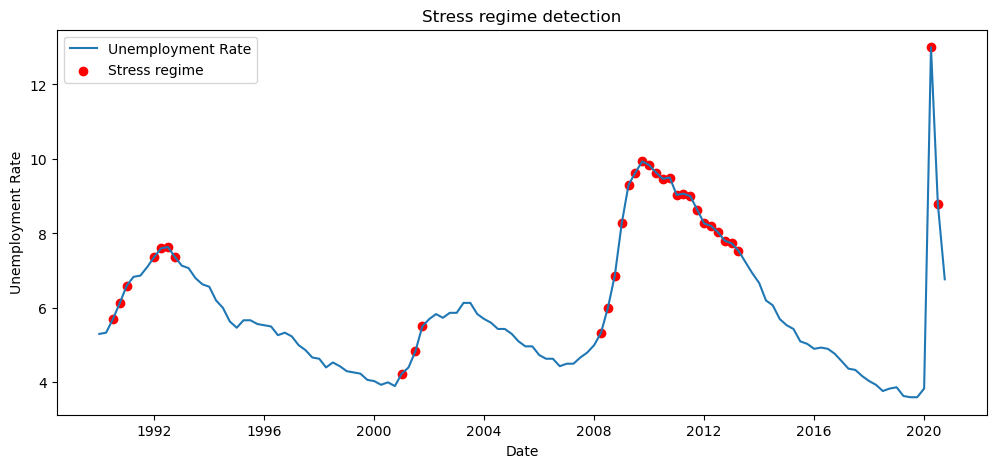

In [12]:
# =========================================================
# 8B. PLOT STRESS REGIME DETECTION
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(full["date"], full["UNRATE"], label="Unemployment Rate")

stress_dates = full.loc[full["stress_flag"] == 1, "date"]

plt.scatter(
    stress_dates,
    full.loc[full["stress_flag"] == 1, "UNRATE"],
    color="red",
    label="Stress regime"
)

plt.title("Stress regime detection")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()

plt.show()

In this stage, the final set of predictor variables used for model training was defined.

In [13]:
# =========================================================
# 9. SELECT FEATURES
# =========================================================
feature_cols = [
    # NGDP dynamics
    "NGDP_lag1", "NGDP_lag2", "NGDP_lag4",

    # unemployment / macro stress
    "UNRATE", "UNRATE_lag1", "UNRATE_lag2",
    "UNRATE_change", "UNRATE_change_lag1", "UNRATE_accel",
    "UNRATE_spike", "UNRATE_spike2",

    # compustat aggregates
    "invt_mean_lag1", "oibdp_mean_lag1", "ppent_mean_lag1", "revt_mean_lag1", "xrd_mean_lag1",
    "invt_med_lag1", "oibdp_med_lag1", "ppent_med_lag1", "revt_med_lag1", "xrd_med_lag1",

    "invt_mean_growth_lag1", "oibdp_mean_growth_lag1", "ppent_mean_growth_lag1", "revt_mean_growth_lag1", "xrd_mean_growth_lag1",
    "invt_med_growth_lag1", "oibdp_med_growth_lag1", "ppent_med_growth_lag1", "revt_med_growth_lag1", "xrd_med_growth_lag1",

    # financial / operating ratios
    "inventory_to_sales_mean_lag1", "capint_mean_lag1", "opmargin_mean_lag1", "rdint_mean_lag1",
    "inventory_to_sales_med_lag1", "capint_med_lag1", "opmargin_med_lag1", "rdint_med_lag1",

    # regime features
    "stress_flag", "stress_x_unrate_change", "stress_x_unrate", "stress_x_ngdp_lag1",

    # quarter
    "q1", "q2", "q3", "q4"
]


The training dataset was constructed by selecting observations from the historical training period and removing rows containing missing values in the predictor variables or the target variable. After this cleaning step, a total of 100 observations remained for model estimation. The dataset was then divided into two subsamples based on the previously defined stress-regime indicator. 

71 observations were classified as normal economic conditions, while 29 observations were identified as stress periods. The stress classification was determined using thresholds derived from the training data, where unusually large increases in unemployment (above 0.3333) or high unemployment levels (above 7.3667) signal potential economic stress. This regime-based split allows the forecasting framework to estimate models that capture different economic dynamics during normal periods and during episodes of economic disruption in later stage.

In [14]:
# =========================================================
# 10. TRAIN DATA
# =========================================================
train_model = full[full["is_train"] == 1].copy()
train_model = train_model.dropna(subset=feature_cols + ["NGDP"]).reset_index(drop=True)

X_train = train_model[feature_cols]
y_train = train_model["NGDP"]

# split by regime
train_normal = train_model[train_model["stress_flag"] == 0].copy()
train_stress = train_model[train_model["stress_flag"] == 1].copy()

X_train_normal = train_normal[feature_cols]
y_train_normal = train_normal["NGDP"]

X_train_stress = train_stress[feature_cols]
y_train_stress = train_stress["NGDP"]

print("Training rows total:", len(train_model))
print("Normal regime rows:", len(train_normal))
print("Stress regime rows:", len(train_stress))
print("Stress threshold (UNRATE_change):", round(spike_thr, 4))
print("High unemployment threshold:", round(level_thr, 4))



Training rows total: 100
Normal regime rows: 71
Stress regime rows: 29
Stress threshold (UNRATE_change): 0.3333
High unemployment threshold: 7.3667


This stage is to create the forecasting models to be used. To improve robustness and capture diverse economic relationships, the modelling strategy combines linear and nonlinear machine learning approaches.

Ridge Regression (baseline linear model)
- Trained using the full training dataset
- Applies L2 regularisation to stabilise coefficient estimates
- Helps mitigate multicollinearity among predictors
- Serves as a simple and stable benchmark model

Random Forest (nonlinear ensemble model)
- Trained on the full training dataset
- Uses 400 decision trees with controlled depth
- Captures nonlinear relationships and interactions among predictors
- Provides stable predictions by averaging across many trees

XGBoost – Normal Regime Model
- Trained only on observations classified as normal economic conditions
- Uses gradient boosting to model complex nonlinear patterns-
- Designed to capture typical macroeconomic dynamics

XGBoost – Stress Regime Model
- Trained on observations identified as economic stress periods
- Uses slightly deeper trees to better capture crisis dynamics
- Includes a fallback mechanism: if the number of stress observations is too small, the model is trained using the full dataset instead

In [16]:
# =========================================================
# 11. FIT MODELS
# =========================================================
# fallback linear model on full sample
ridge_all = Ridge(alpha=2.0)
ridge_all.fit(X_train, y_train)

# random forest on full sample (stability)
rf_all = RandomForestRegressor(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)
rf_all.fit(X_train, y_train)

# normal-regime model
xgb_normal = XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)
xgb_normal.fit(X_train_normal, y_train_normal)

# stress-regime model
# if too few stress rows, fit on full sample as fallback
if len(train_stress) >= 12:
    xgb_stress = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.95,
        colsample_bytree=0.95,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )
    xgb_stress.fit(X_train_stress, y_train_stress)
    stress_model_is_real = True
else:
    xgb_stress = XGBRegressor(
        n_estimators=450,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )
    xgb_stress.fit(X_train, y_train)
    stress_model_is_real = False

print("Stress-specific model trained on stress sample only:", stress_model_is_real)



Stress-specific model trained on stress sample only: True


This section implements recursive forecasting for the test period. Because several predictors, especially lagged GDP growth variables, depend on previous values of the target variable, future observations must be predicted sequentially rather than all at once. 

For each forecast quarter, the feature set and regime indicators are recalculated using the most recent available information, including previously predicted GDP values. Predictions are generated from three models—Ridge regression, Random Forest, and a regime-specific XGBoost model—and combined using weighted averaging. 

During stress periods, greater weight is assigned to the stress-regime XGBoost model, and an additional shock adjustment is applied when unemployment spikes exceed the stress threshold. 

Predicted values are then written back into the dataset, allowing them to serve as lagged inputs for subsequent quarters. 

This recursive procedure ensures that the forecasting process mirrors a realistic out-of-sample setting in which future GDP values are unknown and must be generated sequentially.

In [17]:
# =========================================================
# 12. RECURSIVE FORECAST ON TEST SET
# =========================================================
full_pred = full.copy()
pred_records = []

test_idx = full_pred.index[full_pred["is_test"] == 1].tolist()

for idx in test_idx:
    # rebuild features each iteration because lagged NGDP must use prior predictions
    full_pred = make_features(full_pred)
    full_pred = add_regime_flags(full_pred, spike_thr, level_thr)

    row = full_pred.loc[idx, feature_cols]

    if row.isna().any():
        print(f"Skipping {full_pred.loc[idx, 'YQ']} due to missing predictors.")
        continue

    x_row = pd.DataFrame([row.values], columns=feature_cols)

    p_ridge = ridge_all.predict(x_row)[0]
    p_rf = rf_all.predict(x_row)[0]

    # choose regime-specific xgb
    stress_now = int(full_pred.loc[idx, "stress_flag"])

    if stress_now == 1:
        p_xgb = xgb_stress.predict(x_row)[0]

        # stronger reaction in stress periods:
        # more weight on stress model, some ridge/rf for stabilization
        pred = 0.20 * p_ridge + 0.15 * p_rf + 0.65 * p_xgb

        # optional shock amplification based on unemployment spike
        # keeps the model more responsive to crisis-like quarters
        shock_adj = 0

        if full_pred.loc[idx, "UNRATE_change"] > spike_thr:
            shock_adj = -1.2 * full_pred.loc[idx, "UNRATE_spike"]

        pred = pred + shock_adj

        # prevent unrealistic extreme forecasts
        pred = np.clip(pred, -30, 30)

    else:
        p_xgb = xgb_normal.predict(x_row)[0]
        pred = 0.20 * p_ridge + 0.20 * p_rf + 0.60 * p_xgb

    pred_records.append({
        "YQ": full_pred.loc[idx, "YQ"],
        "stress_flag": stress_now,
        "p_ridge": p_ridge,
        "p_rf": p_rf,
        "p_xgb": p_xgb,
        "NGDP_pred": pred
    })

    # recursive update
    full_pred.loc[idx, "NGDP"] = pred

pred_df = pd.DataFrame(pred_records)

print(pred_df)



        YQ  stress_flag     p_ridge      p_rf     p_xgb  NGDP_pred
0   2016Q1            0    2.006657  2.569099  3.884941   3.246116
1   2016Q2            0    2.833937  2.926480  3.746697   3.400101
2   2016Q3            0    2.935428  2.510525  2.059153   2.324683
3   2016Q4            0    3.366079  2.703166  2.551712   2.744876
4   2017Q1            0    3.387970  2.614542  3.683608   3.410667
5   2017Q2            0    3.622309  2.633262  4.230517   3.789425
6   2017Q3            0    3.266801  2.760851  1.761116   2.262200
7   2017Q4            0    3.000518  2.496131  2.105287   2.362502
8   2018Q1            0    3.551162  2.948159  3.911177   3.646571
9   2018Q2            0    3.185757  2.476717  4.324259   3.727050
10  2018Q3            0    3.591566  2.618307  2.208064   2.566813
11  2018Q4            0    2.840867  2.557596  1.816588   2.169646
12  2019Q1            0    1.833937  2.785433  4.198538   3.442997
13  2019Q2            0    0.944186  2.388720  5.200526   3.78

The forecasting performance was evaluated by comparing the predicted GDP growth series with the external proxy variable GDP_PCA.

A quarter-by-quarter comparison suggests that the model performs relatively well during normal economic periods between 2016 and 2019, where predicted GDP values generally follow the trend of the proxy series. 

The model also successfully identifies the economic contraction in 2020Q2, producing a large negative forecast close to the proxy value. 

However, the model substantially underestimates the rapid recovery in 2020Q3, which increases the overall RMSE.

Conclusion: The validation results suggest that the model captures general macroeconomic trends and downturns reasonably well but has limited ability to fully reflect extremely sharp post-crisis rebounds.

In [18]:
# =========================================================
# 13. VALIDATE AGAINST GDP_PCA PROXY
# =========================================================
pred_df = pred_df.merge(gdp_pca[["YQ", "GDP_PCA"]], on="YQ", how="left")

valid = pred_df.dropna(subset=["GDP_PCA"]).copy()

rmse = np.sqrt(mean_squared_error(valid["GDP_PCA"], valid["NGDP_pred"]))
mae = np.mean(np.abs(valid["GDP_PCA"] - valid["NGDP_pred"]))

print("\nValidation against GDP_PCA proxy")
print("RMSE:", round(rmse, 6))
print("MAE :", round(mae, 6))

print("\nPredictions vs GDP_PCA:")
print(valid[["YQ", "stress_flag", "NGDP_pred", "GDP_PCA"]])




Validation against GDP_PCA proxy
RMSE: 8.016489
MAE : 3.51154

Predictions vs GDP_PCA:
        YQ  stress_flag  NGDP_pred  GDP_PCA
0   2016Q1            0   3.246116      2.0
1   2016Q2            0   3.400101      4.1
2   2016Q3            0   2.324683      3.9
3   2016Q4            0   2.744876      4.2
4   2017Q1            0   3.410667      4.1
5   2017Q2            0   3.789425      3.3
6   2017Q3            0   2.262200      5.3
7   2017Q4            0   2.362502      7.2
8   2018Q1            0   3.646571      5.9
9   2018Q2            0   3.727050      5.1
10  2018Q3            0   2.566813      4.3
11  2018Q4            0   2.169646      2.3
12  2019Q1            0   3.442997      3.8
13  2019Q2            0   3.786897      5.5
14  2019Q3            0   1.915009      6.1
15  2019Q4            0   1.948594      4.0
16  2020Q1            0   2.369222     -3.3
17  2020Q2            1 -30.000000    -29.1
18  2020Q3            1   5.619355     39.9
19  2020Q4            0   5.6460

The model’s predictive performance was further evaluated by separating the validation period:-
- Normal economic conditions (2016Q1–2019Q4)
- Crisis period (2020Q1–2020Q4)

The results show that the model performs significantly better during normal economic conditions, with an RMSE of 2.16 for the period 2016–2019. This indicates that the model is able to capture typical GDP fluctuations relatively accurately during stable periods.

For forecasting accuracy deteriorates during the crisis period, the RMSE increases to 17.39. The higher error is largely driven by the extreme volatility during the COVID-19 shock, particularly the sharp contraction in 2020Q2 and the unusually strong rebound in 2020Q3. Such extreme movements are difficult for models trained on historical data to fully capture.

In [19]:
# =========================================================
# 14. NORMAL-PERIOD VS CRISIS-PERIOD DIAGNOSTICS
# =========================================================
pre2020 = valid[valid["YQ"] < "2020Q1"].copy()
yr2020 = valid[valid["YQ"] >= "2020Q1"].copy()

if len(pre2020) > 0:
    rmse_pre2020 = np.sqrt(mean_squared_error(pre2020["GDP_PCA"], pre2020["NGDP_pred"]))
    print("\nRMSE for 2016Q1-2019Q4:", round(rmse_pre2020, 6))

if len(yr2020) > 0:
    rmse_2020 = np.sqrt(mean_squared_error(yr2020["GDP_PCA"], yr2020["NGDP_pred"]))
    print("RMSE for 2020Q1-2020Q4:", round(rmse_2020, 6))




RMSE for 2016Q1-2019Q4: 2.161516
RMSE for 2020Q1-2020Q4: 17.396319


The final predicted GDP growth values were merged with the test dataset and formatted according to the required submission structure. The predicted variable was renamed to NGDP and rounded to one decimal place for consistency.

In [20]:
# =========================================================
# 15. SAVE SUBMISSION
# =========================================================
submission = test[["YQ"]].merge(pred_df[["YQ", "NGDP_pred"]], on="YQ", how="left")
submission = submission.rename(columns={"NGDP_pred": "NGDP"})
submission["NGDP"] = submission["NGDP"].round(1)

submission.to_csv("NGDP_submission_regime_awarev2.csv", index=False)